In [6]:
%pip install matplotlib cartopy numpy xarray urllib

ERROR: Could not find a version that satisfies the requirement urllib (from versions: none)
ERROR: No matching distribution found for urllib
Note: you may need to restart the kernel to use updated packages.


In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import urllib.request
import cartopy
import cartopy.io.shapereader as shpreader

In [2]:
#Instructions for using the code: Click the run button to start running the program. The code will prompt the user to input a year (integer) from 1987
#to 2022, inclusive on both ends. Once the user inputs a year of their choosing given the constraints, the code will then prompt the user for a name
#that was used for the given year that was inputted by the user. The user must type in a name (string) that was used during the user specified year, or
#hurricane season. If the user inputs an invalid name, the program will prompt the user again to input a proper name. Upon inputting a valid name, the
#code will execute and output watches and warnings associated with the specified storm of the specified year.

#This method searches for a name which will be input by the user for a given year, also inputted by the user, and either returns a string of data 
    #accessed via an url or a printed statement saying that the inputted name was not used during the given season if the name is not found.
    #It also has an internal counter, i, that will act as a dynamic variable to allow for the search of a name through the multiple data files
    #associated with a singular year. There are 5 data files associated with each hurricane season (year) so the internal counter will start at 1
    #and increment by 1 during each iteration until either a name in a certain text file is found OR until the internal counter, i, reaches 6.
    #Once i reaches 6, the if(i>5) statement will become true and a statement saying that the user inputted name was not used during the specified
    #season and will break out of the while-loop. If a name is found in a certain text file, that text file will be return and later modified to access
    #certain locations that were issued tropical storm/hurricane watches/warnings. 
def find_name(year, name):
    found = False
    i = 1
    while(found != True):
        str(i)
        url = f'https://mesonet.agron.iastate.edu/json/nwstext_search.py?sts={year}-01-01T00:00Z&ets={year}-12-31T23:59Z&awipsid=TCPAT{i}'
        infile = urllib.request.urlopen(url)
        f = infile.read()
        f = str(f).upper()
        if(f.find(name.upper()) != -1):
            found = True;
            return f
        else:
            int(i)
            i+=1 
        if(i>5):
            print(f'{name} is not a name that was used during the {year} hurricane season')
            break;
        
#This method prompts a user to input a name associated with a specified hurricane season (year); it returns the user's inputted name with
    #white space on both ends to account for names that could be parts of words. This method is called multiple times in the code (if necessary)
    #to account for possible spelling mistakes or user error.
def request_name():
    name = input('Please input a name for a tropical cyclone that occurred that year for its associated watches and warnings')
    return " " + name + " "

#This method accesses the data files and checks for key words that may exist in a certain index of a list. The method
    #traverses through every index of the list and removed the index if the keywords are not found. The index gets
    #incremented if the index is kept and does not increment if the index if removed. Furthermore, if all indices
    #get removed, the method prints a statement saying that there were no watches or warnings associated with user 
    #inputted storm.
def access_advisory(array):
    i = 0;
    while i < len(array):
        if(array[i].find('TROPICAL STORM WATCH') == -1 and array[i].find('TROPICAL STORM WARNING') == -1 and array[i].find('HURRICANE WATCH') == -1 and array[i].find('HURRICANE WARNING') == -1):
            array.remove(array[i])
        else:
            i += 1
    if(len(array) == 0):
        print("There are no watches and warnings associated with this system.")
        quit()
    return array

#A method that adds singular states, islands, or countries to a list that will be used for graphing. The lands added
    #to these lists will become highlighted on a graph as either hurricane watch/warning or tropical storm watch/warning.
    #It returns a list that contains states, islands, or countries that were found to be in the url data file and have watches or warnings
    #associated with the specified storm of a specified year. It also ensures that the list parameter is modified to only contain the land
    #masses mentioned by returning a list that is temporarily used to append land to. This temporary list is returned when the method is complete.
def obtain_regions(array):
    temp = [];
    for i in array:
        for x in list_land:
            for y in x:
                if(i.find(y) != -1):
                    temp.append(y)
    return temp   
    
#A method that allows the programmer to see what values are contained in each index of any list at any point 
    #during the programming and debugging process. Very useful for accessing values in lists or to test if a list or a loop that modifies a
    #list is working as expected. This method will not be used in the final product of this project as it has no application to the functionality
    #of this program and was created strictly for the debugging process. I figured I'd leave it in here as it was a vital piece to understanding
    #errors in my code and that it would not do any harm to leave it as an extra, unused method.
def test_print(array):
    for i in array:
        print(i)
        print('------------')

#Here are the declarations of variables that will be used in this code. The first four lists are acting as libraries of places that can used to check
    #against lands that have been issues watches or warnings for a specified tropical system. The fifth list, list_land, puts the lists of lands into
    #one list so that all 4 lists can be accessed and traversed in a single shot. The sixth through eleventh lists are used to hold that will change
    #during the program run. The twelth list, list_places, will keep a list of lists of places that were issued tropical storm watches, tropical storm
    #warnings, hurricane watches, and hurricane warnings respectively that can be easily traversed through and accessed easily from a single location;
    #that location being list_places. 
crbn_isles =["ANGUILLA", "ANTIGUA", "ARUBA", "BAHAMAS", "BARBADOS", "BARBUDA", "BONAIRE", "BRITISH VIRGIN ISLANDS", "CAYMAN ISLANDS", "CUBA", "CULEBRA", "DOMINICA", "DOMINICAN REPUBLIC", "GREATER ANTILLES", "GRENADA", "GUADELOUPE", "HAITI", "JAMAICA", "LEEWARD ISLANDS", "LESSER ANTILLES", "MARTINIQUE", "MONTSERRAT", "NAVASSA ISLAND", "NETHERLANDS ANTILLES", "PUERTO RICO", "SAN JUAN", "SAINT BARTHELEMY", "SAINT KITTS AND NEVIS", "SAINT LUCIA", "SAINT MARTIN", "SAINT VINCENT AND THE GRENADINES", "TRINIDAD AND TOBAGO", "TURKS AND CAICOS", "U.S. VIRGIN ISLANDS", "US VIRGIN ISLANDS", "UNITED STATES VIRGIN ISLANDS", "VIEQUES"]
US_STATES = ["ALABAMA", "ARKANSAS", "CONNECTICUT", "DELAWARE", "FLORIDA", "GEORGIA", "LONG ISALND", "LOUISIANA", "MAINE", "MARYLAND", "MASSACHUSETTS", "MISSISSIPPI", "MISSOURI", "NEW HAMPSHIRE", "NEW JERSEY", "NEW YORK", "NEW YORK CITY", "NORTH CAROLINA", "PENNSYLVANIA", "RHODE ISLAND", "SOUTH CAROLINA", "TENNESSEE", "TEXAS", "VERMONT", "VIRGINIA", "WEST VIRGINIA", "WASHINGTON D.C."]
MEX_STATES = ["AGUASCALIENTES", "BAJA CALIFORNIA", "BAJA CALIFORNIA SUR", "CAMPECHE", "CHIAPAS", "CHIHUAHUA", "COAHUILA", "COLIMA", "DURANGO", "GUANAJUATO", "GUERRERO", "HIDALGO", "JALISCO", "MEXICO CITY", "MEXICO", "MICHOACÁN", "MICHOACAN", "MORELOS", "NAYARIT", "NUEVO LEON", "OAXACA", "PUEBLA", "QUERETARO", "QUINTANA ROO", "SAN LUIS POTOSÍ", "SAN LUIS POTOSI", "SINALOA", "SONORA", "TABASCO", "TAMAULIPAS", "TLAXCALA", "VERACRUZ", "YUCATAN", "YUCATÁN", "ZACATECAS"]
XTRA_COUNTRIES = ["BELIZE", "GUATAMALA", "HONDURAS", "EL SALVADOR", "NICARAGUA", "COSTA RICA", "PANAMA", "VENEZUELA", "GUYANA"]
list_land = [crbn_isles, US_STATES, MEX_STATES, XTRA_COUNTRIES];
wx_statements = [];
storm_advisories = [];
hurr_warn_places = [];
hurr_watch_places = [];
ts_warn_places = [];
ts_watch_places = [];
list_places = [ts_watch_places, ts_warn_places, hurr_watch_places, hurr_warn_places];

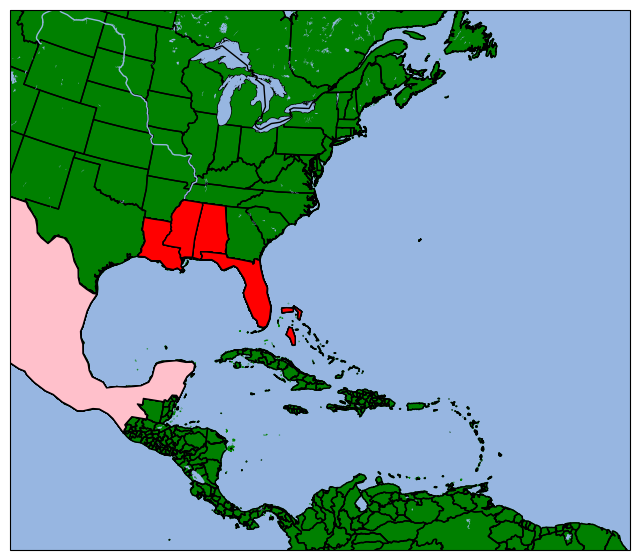

In [3]:
##Here will be code that will ask a user for a specific year from 1987 to 2022 and a storm name associated with
##that year. If a name chosen for a specific year does not exist, throw error that says invalid name for year
##and repeats request for user input. 
year = input('Please select a year between 1987-2022 for a hurricane season')
try: 
    while(1987 > int(year) or int(year) > 2022):
        year = input('Invalid year, please input a proper year that is between 1987-2022 inclusive.')
except ValueError:
    year = input('Invalid year, please input a proper year (integer) that is between 1987-2022 inclusive.')
        
name = request_name()
year = str(year)

f = find_name(year, name)

#Puts user in loop that only terminates when user inputs a valid storm name
if(f == None):
    while(f == None):
        name = request_name()
        f = find_name(year, name)

#The next 5 lines convert the text file found to all uppercase characters to make traversing and identifying words and phrases much easier. The next
    #lines of code also include a for-loop that goes through every line of the newly split string, f, which was put into a list, wx_statements.
    #The for-loop will traverse through every index of the wx_statements list and find specific indices of wx_statements where the name that the user
    #input is mentioned and add it to another list called storm_adivsories.
f.upper()
wx_statements = f.split('-')
for line in wx_statements:
    if(line.find(name.upper()) != -1):
        storm_advisories.append(line)

#storm_advisories is being reassigned values that had been modified by using the access_advisory() method. (go to its definition for a description
    #on how the method works)
storm_advisories = access_advisory(storm_advisories)

#This for loop goes through every index of storm_advisories and splits each sentence in an index, i, into a list, temp. Then every sentence (index) in
    #temp will be traverse and compared to key phrases. If there is a match with the key phrases, the loop will also make sure that some other key phrases
    #are not used to ensure that only official watches or warnings are added to their resepctive watch/warn list.
for i in storm_advisories:
    temp = i.split('. ')
    for j in temp:
        if(j.find("HURRICANE WARNING") != -1 and j.find("MEANS") == -1 and j.find("MAY BE REQUIRED") == -1 and j.find("DISCONTINUED") == -1):
            hurr_warn_places.append(j)
        elif(j.find("TROPICAL STORM WARNING") != -1 and j.find("MEANS") == -1 and j.find("MAY BE REQUIRED") == -1 and j.find("DISCONTINUED") == -1):
            ts_warn_places.append(j)
        elif(j.find("HURRICANE WATCH") != -1 and j.find("MEANS") == -1 and j.find("MAY BE REQUIRED") == -1 and j.find("DISCONTINUED") == -1):
            hurr_watch_places.append(j)
        elif(j.find("TROPICAL STORM WATCH") != -1 and j.find("MEANS") == -1 and j.find("MAY BE REQUIRED") == -1 and j.find("DISCONTINUED") == -1):
            ts_watch_places.append(j)

index = 0
#This while loop obtains only a list of places where watches and/or warnings have been issues. It will traverse through each list in list_places and
    #compare the places that were appened as strings and search for specific keywords that will then add that keyword to a list if its match is found.
while(index < len(list_places)):
    list_places[index] = obtain_regions(list_places[index])
    index += 1


index = 0
#Here we can somewhat reduce repition in lists. It will compare a temporary string to strings from later indicies and deletes the index that is being
    #compared if the temporary string and the string from the later index are equal to each other.  
try:
    while(len(list_places) > index):
        i = 1
        temp = list_places[index][0]
        while(len(list_places[index]) > i):
            if(list_places[index][i] == temp):
                list_places[index].remove(list_places[index][i])
            else:
                temp = list_places[index][i]
                i += 1
        index += 1
except IndexError:
    pass;
        
#Defines the map projection
projection = ccrs.AlbersEqualArea(central_latitude=40, central_longitude=-74)

#Read in the shapefile of the US states so that their geometries can be used for mapping.
shpfilename = shpreader.natural_earth(resolution='110m', category='cultural', name='admin_1_states_provinces')
states_shp = shpreader.Reader(shpfilename)

# Find the geometry for the desired state(s). It keeps track of which places were issued what advisories.
tswatch = [];
tswarn = [];
hurrwatch = [];
hurrwarn = [];
count = 0;
for state in states_shp.records():
    count = 0
    for sublist in list_places:
        for s in sublist:
            if(state.attributes['name'].upper().find(s) != -1 and s.find('MEXICO') == -1):
                if(count == 0):
                    tswatch.append(state.geometry)
                if(count == 1):
                    tswarn.append(state.geometry)
                if(count == 2):
                    hurrwatch.append(state.geometry)
                if(count == 3):
                    hurrwarn.append(state.geometry)
        count += 1

#Read in the shapefile of the countries so that their geometries can be used for mapping.
shpfilename = shpreader.natural_earth(resolution='110m', category='cultural', name='admin_0_countries')
countries_shp = shpreader.Reader(shpfilename)

count = 0;
#Find the geometry for the desired country(ies). It keeps track of which places were issued what advisories.
for country in countries_shp.records():
    count = 0;
    for sublist in list_places:
        for s in sublist:
            if(country.attributes['NAME'].upper().find(s) != -1):
                if(count == 0):
                    tswatch.append(country.geometry)
                if(count == 1):
                    tswarn.append(country.geometry)
                if(count == 2):
                    hurrwatch.append(country.geometry)
                if(count == 3):
                    hurrwarn.append(country.geometry)
        count += 1

# Creates a figure and add features to the map. The map created will be a map of the United States, Mexico, Central America, and the Caribbean.
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, projection=projection)
ax.add_feature(cfeature.STATES.with_scale('10m'), edgecolor= 'black')
ax.add_feature(cfeature.OCEAN.with_scale('10m'))
ax.add_feature(cfeature.LAKES.with_scale('10m'))
ax.add_feature(cfeature.LAND.with_scale('10m'), color='g')
ax.add_feature(cfeature.BORDERS.with_scale('10m'))
ax.add_feature(cartopy.feature.RIVERS)

# Add the state/country geometries to the map in order of tropical storm watch, tropical storm warning, hurricane watch, then hurricane warning.
    #This is to ensure that the 'worst' advisory for a state or country be shown.
ax.add_geometries(tswatch, crs=ccrs.PlateCarree(), facecolor='yellow', edgecolor='black')
ax.add_geometries(tswarn, crs=ccrs.PlateCarree(), facecolor='blue', edgecolor='black')
ax.add_geometries(hurrwatch, crs=ccrs.PlateCarree(), facecolor='pink', edgecolor='black')
ax.add_geometries(hurrwarn, crs=ccrs.PlateCarree(), facecolor='red', edgecolor='black')

# Set the extent of the map to show the desired region which is the Easter Contingent United States, Mexico, Central America, and the Caribbean. 
ax.set_extent([-100, -50, 5, 50])

## Here is our modified code to be 2025 inclusive

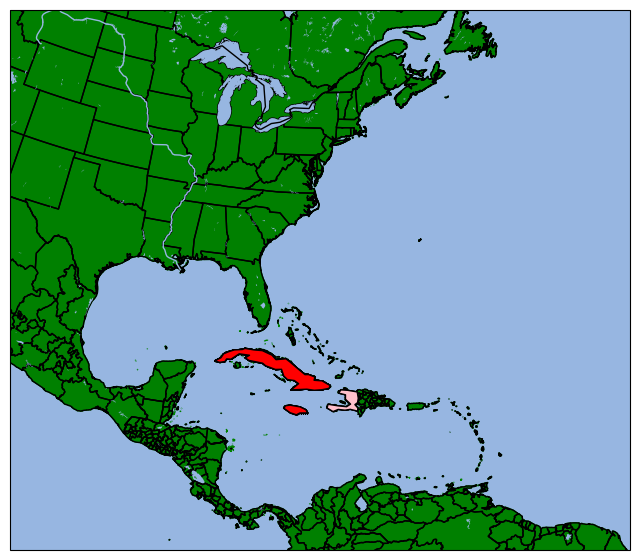

In [4]:
crbn_isles =["ANGUILLA", "ANTIGUA", "ARUBA", "BAHAMAS", "BARBADOS", "BARBUDA", "BONAIRE", "BRITISH VIRGIN ISLANDS", "CAYMAN ISLANDS", "CUBA", "CULEBRA", "DOMINICA", "DOMINICAN REPUBLIC", "GREATER ANTILLES", "GRENADA", "GUADELOUPE", "HAITI", "JAMAICA", "LEEWARD ISLANDS", "LESSER ANTILLES", "MARTINIQUE", "MONTSERRAT", "NAVASSA ISLAND", "NETHERLANDS ANTILLES", "PUERTO RICO", "SAN JUAN", "SAINT BARTHELEMY", "SAINT KITTS AND NEVIS", "SAINT LUCIA", "SAINT MARTIN", "SAINT VINCENT AND THE GRENADINES", "TRINIDAD AND TOBAGO", "TURKS AND CAICOS", "U.S. VIRGIN ISLANDS", "US VIRGIN ISLANDS", "UNITED STATES VIRGIN ISLANDS", "VIEQUES"]
US_STATES = ["ALABAMA", "ARKANSAS", "CONNECTICUT", "DELAWARE", "FLORIDA", "GEORGIA", "LONG ISALND", "LOUISIANA", "MAINE", "MARYLAND", "MASSACHUSETTS", "MISSISSIPPI", "MISSOURI", "NEW HAMPSHIRE", "NEW JERSEY", "NEW YORK", "NEW YORK CITY", "NORTH CAROLINA", "PENNSYLVANIA", "RHODE ISLAND", "SOUTH CAROLINA", "TENNESSEE", "TEXAS", "VERMONT", "VIRGINIA", "WEST VIRGINIA", "WASHINGTON D.C."]
MEX_STATES = ["AGUASCALIENTES", "BAJA CALIFORNIA", "BAJA CALIFORNIA SUR", "CAMPECHE", "CHIAPAS", "CHIHUAHUA", "COAHUILA", "COLIMA", "DURANGO", "GUANAJUATO", "GUERRERO", "HIDALGO", "JALISCO", "MEXICO CITY", "MEXICO", "MICHOACÁN", "MICHOACAN", "MORELOS", "NAYARIT", "NUEVO LEON", "OAXACA", "PUEBLA", "QUERETARO", "QUINTANA ROO", "SAN LUIS POTOSÍ", "SAN LUIS POTOSI", "SINALOA", "SONORA", "TABASCO", "TAMAULIPAS", "TLAXCALA", "VERACRUZ", "YUCATAN", "YUCATÁN", "ZACATECAS"]
XTRA_COUNTRIES = ["BELIZE", "GUATAMALA", "HONDURAS", "EL SALVADOR", "NICARAGUA", "COSTA RICA", "PANAMA", "VENEZUELA", "GUYANA"]
list_land = [crbn_isles, US_STATES, MEX_STATES, XTRA_COUNTRIES];
wx_statements = [];
storm_advisories = [];
hurr_warn_places = [];
hurr_watch_places = [];
ts_warn_places = [];
ts_watch_places = [];
list_places = [ts_watch_places, ts_warn_places, hurr_watch_places, hurr_warn_places];

##Here will be code that will ask a user for a specific year from 1987 to 2022 and a storm name associated with
##that year. If a name chosen for a specific year does not exist, throw error that says invalid name for year
##and repeats request for user input. 
year = input('Please select a year between 1987-2025 for a hurricane season')
try: 
    while(1987 > int(year) or int(year) > 2025):
        year = input('Invalid year, please input a proper year that is between 1987-2025 inclusive.')
except ValueError:
    year = input('Invalid year, please input a proper year (integer) that is between 1987-2025 inclusive.')
        
name = request_name()
year = str(year)

f = find_name(year, name)

#Puts user in loop that only terminates when user inputs a valid storm name
if(f == None):
    while(f == None):
        name = request_name()
        f = find_name(year, name)

#The next 5 lines convert the text file found to all uppercase characters to make traversing and identifying words and phrases much easier. The next
    #lines of code also include a for-loop that goes through every line of the newly split string, f, which was put into a list, wx_statements.
    #The for-loop will traverse through every index of the wx_statements list and find specific indices of wx_statements where the name that the user
    #input is mentioned and add it to another list called storm_adivsories.
f.upper()
wx_statements = f.split('-')
for line in wx_statements:
    if(line.find(name.upper()) != -1):
        storm_advisories.append(line)

#storm_advisories is being reassigned values that had been modified by using the access_advisory() method. (go to its definition for a description
    #on how the method works)
storm_advisories = access_advisory(storm_advisories)

#This for loop goes through every index of storm_advisories and splits each sentence in an index, i, into a list, temp. Then every sentence (index) in
    #temp will be traverse and compared to key phrases. If there is a match with the key phrases, the loop will also make sure that some other key phrases
    #are not used to ensure that only official watches or warnings are added to their resepctive watch/warn list.
for i in storm_advisories:
    temp = i.split('. ')
    for j in temp:
        if(j.find("HURRICANE WARNING") != -1 and j.find("MEANS") == -1 and j.find("MAY BE REQUIRED") == -1 and j.find("DISCONTINUED") == -1):
            hurr_warn_places.append(j)
        elif(j.find("TROPICAL STORM WARNING") != -1 and j.find("MEANS") == -1 and j.find("MAY BE REQUIRED") == -1 and j.find("DISCONTINUED") == -1):
            ts_warn_places.append(j)
        elif(j.find("HURRICANE WATCH") != -1 and j.find("MEANS") == -1 and j.find("MAY BE REQUIRED") == -1 and j.find("DISCONTINUED") == -1):
            hurr_watch_places.append(j)
        elif(j.find("TROPICAL STORM WATCH") != -1 and j.find("MEANS") == -1 and j.find("MAY BE REQUIRED") == -1 and j.find("DISCONTINUED") == -1):
            ts_watch_places.append(j)

index = 0
#This while loop obtains only a list of places where watches and/or warnings have been issues. It will traverse through each list in list_places and
    #compare the places that were appened as strings and search for specific keywords that will then add that keyword to a list if its match is found.
while(index < len(list_places)):
    list_places[index] = obtain_regions(list_places[index])
    index += 1


index = 0
#Here we can somewhat reduce repition in lists. It will compare a temporary string to strings from later indicies and deletes the index that is being
    #compared if the temporary string and the string from the later index are equal to each other.  
try:
    while(len(list_places) > index):
        i = 1
        temp = list_places[index][0]
        while(len(list_places[index]) > i):
            if(list_places[index][i] == temp):
                list_places[index].remove(list_places[index][i])
            else:
                temp = list_places[index][i]
                i += 1
        index += 1
except IndexError:
    pass;
        
#Defines the map projection
projection = ccrs.AlbersEqualArea(central_latitude=40, central_longitude=-74)

#Read in the shapefile of the US states so that their geometries can be used for mapping.
shpfilename = shpreader.natural_earth(resolution='110m', category='cultural', name='admin_1_states_provinces')
states_shp = shpreader.Reader(shpfilename)

# Find the geometry for the desired state(s). It keeps track of which places were issued what advisories.
tswatch = [];
tswarn = [];
hurrwatch = [];
hurrwarn = [];
count = 0;
for state in states_shp.records():
    count = 0
    for sublist in list_places:
        for s in sublist:
            if(state.attributes['name'].upper().find(s) != -1 and s.find('MEXICO') == -1):
                if(count == 0):
                    tswatch.append(state.geometry)
                if(count == 1):
                    tswarn.append(state.geometry)
                if(count == 2):
                    hurrwatch.append(state.geometry)
                if(count == 3):
                    hurrwarn.append(state.geometry)
        count += 1

#Read in the shapefile of the countries so that their geometries can be used for mapping.
shpfilename = shpreader.natural_earth(resolution='110m', category='cultural', name='admin_0_countries')
countries_shp = shpreader.Reader(shpfilename)

count = 0;
#Find the geometry for the desired country(ies). It keeps track of which places were issued what advisories.
for country in countries_shp.records():
    count = 0;
    for sublist in list_places:
        for s in sublist:
            if(country.attributes['NAME'].upper().find(s) != -1):
                if(count == 0):
                    tswatch.append(country.geometry)
                if(count == 1):
                    tswarn.append(country.geometry)
                if(count == 2):
                    hurrwatch.append(country.geometry)
                if(count == 3):
                    hurrwarn.append(country.geometry)
        count += 1

# Creates a figure and add features to the map. The map created will be a map of the United States, Mexico, Central America, and the Caribbean.
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, projection=projection)
ax.add_feature(cfeature.STATES.with_scale('10m'), edgecolor= 'black')
ax.add_feature(cfeature.OCEAN.with_scale('10m'))
ax.add_feature(cfeature.LAKES.with_scale('10m'))
ax.add_feature(cfeature.LAND.with_scale('10m'), color='g')
ax.add_feature(cfeature.BORDERS.with_scale('10m'))
ax.add_feature(cartopy.feature.RIVERS)

# Add the state/country geometries to the map in order of tropical storm watch, tropical storm warning, hurricane watch, then hurricane warning.
    #This is to ensure that the 'worst' advisory for a state or country be shown.
ax.add_geometries(tswatch, crs=ccrs.PlateCarree(), facecolor='yellow', edgecolor='black')
ax.add_geometries(tswarn, crs=ccrs.PlateCarree(), facecolor='blue', edgecolor='black')
ax.add_geometries(hurrwatch, crs=ccrs.PlateCarree(), facecolor='pink', edgecolor='black')
ax.add_geometries(hurrwarn, crs=ccrs.PlateCarree(), facecolor='red', edgecolor='black')

# Set the extent of the map to show the desired region which is the Easter Contingent United States, Mexico, Central America, and the Caribbean. 
ax.set_extent([-100, -50, 5, 50])

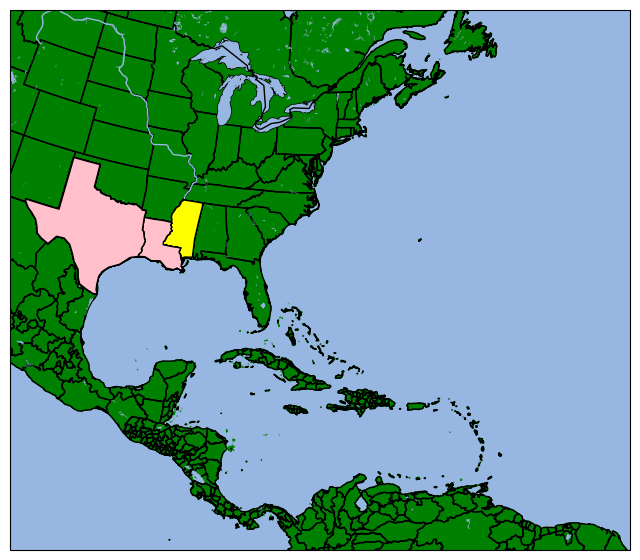

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import urllib.request
import cartopy
import cartopy.io.shapereader as shpreader

#This method searches for a name which will be input by the user for a given year, also inputted by the user, and either returns a string of data 
    #accessed via an url or a printed statement saying that the inputted name was not used during the given season if the name is not found.
    #It also has an internal counter, i, that will act as a dynamic variable to allow for the search of a name through the multiple data files
    #associated with a singular year. There are 5 data files associated with each hurricane season (year) so the internal counter will start at 1
    #and increment by 1 during each iteration until either a name in a certain text file is found OR until the internal counter, i, reaches 6.
    #Once i reaches 6, the if(i>5) statement will become true and a statement saying that the user inputted name was not used during the specified
    #season and will break out of the while-loop. If a name is found in a certain text file, that text file will be return and later modified to access
    #certain locations that were issued tropical storm/hurricane watches/warnings. 
def find_name(year, name):
    found = False
    i = 1
    while(found != True):
        str(i)
        url = f'https://mesonet.agron.iastate.edu/json/nwstext_search.py?sts={year}-01-01T00:00Z&ets={year}-12-31T23:59Z&awipsid=TCPAT{i}'
        infile = urllib.request.urlopen(url)
        f = infile.read()
        f = str(f).upper()
        if(f.find(name.upper()) != -1):
            found = True;
            return f
        else:
            int(i)
            i+=1 
        if(i>5):
            print(f'{name} is not a name that was used during the {year} hurricane season')
            break;
        
#This method prompts a user to input a name associated with a specified hurricane season (year); it returns the user's inputted name with
    #white space on both ends to account for names that could be parts of words. This method is called multiple times in the code (if necessary)
    #to account for possible spelling mistakes or user error.
def request_name():
    name = input('Please input a name for a tropical cyclone that occurred that year for its associated watches and warnings')
    return " " + name + " "

#This method accesses the data files and checks for key words that may exist in a certain index of a list. The method
    #traverses through every index of the list and removed the index if the keywords are not found. The index gets
    #incremented if the index is kept and does not increment if the index if removed. Furthermore, if all indices
    #get removed, the method prints a statement saying that there were no watches or warnings associated with user 
    #inputted storm.
def access_advisory(array):
    i = 0;
    while i < len(array):
        if(array[i].find('TROPICAL STORM WATCH') == -1 and array[i].find('TROPICAL STORM WARNING') == -1 and array[i].find('HURRICANE WATCH') == -1 and array[i].find('HURRICANE WARNING') == -1):
            array.remove(array[i])
        else:
            i += 1
    if(len(array) == 0):
        print("There are no watches and warnings associated with this system.")
        quit()
    return array

#A method that adds singular states, islands, or countries to a list that will be used for graphing. The lands added
    #to these lists will become highlighted on a graph as either hurricane watch/warning or tropical storm watch/warning.
    #It returns a list that contains states, islands, or countries that were found to be in the url data file and have watches or warnings
    #associated with the specified storm of a specified year. It also ensures that the list parameter is modified to only contain the land
    #masses mentioned by returning a list that is temporarily used to append land to. This temporary list is returned when the method is complete.
def obtain_regions(array):
    temp = [];
    for i in array:
        for x in list_land:
            for y in x:
                if(i.find(y) != -1):
                    temp.append(y)
    return temp   
    
#A method that allows the programmer to see what values are contained in each index of any list at any point 
    #during the programming and debugging process. Very useful for accessing values in lists or to test if a list or a loop that modifies a
    #list is working as expected. This method will not be used in the final product of this project as it has no application to the functionality
    #of this program and was created strictly for the debugging process. I figured I'd leave it in here as it was a vital piece to understanding
    #errors in my code and that it would not do any harm to leave it as an extra, unused method.
def test_print(array):
    for i in array:
        print(i)
        print('------------')

#Here are the declarations of variables that will be used in this code. The first four lists are acting as libraries of places that can used to check
    #against lands that have been issues watches or warnings for a specified tropical system. The fifth list, list_land, puts the lists of lands into
    #one list so that all 4 lists can be accessed and traversed in a single shot. The sixth through eleventh lists are used to hold that will change
    #during the program run. The twelth list, list_places, will keep a list of lists of places that were issued tropical storm watches, tropical storm
    #warnings, hurricane watches, and hurricane warnings respectively that can be easily traversed through and accessed easily from a single location;
    #that location being list_places. 
crbn_isles =["ANGUILLA", "ANTIGUA", "ARUBA", "BAHAMAS", "BARBADOS", "BARBUDA", "BONAIRE", "BRITISH VIRGIN ISLANDS", "CAYMAN ISLANDS", "CUBA", "CULEBRA", "DOMINICA", "DOMINICAN REPUBLIC", "GREATER ANTILLES", "GRENADA", "GUADELOUPE", "HAITI", "JAMAICA", "LEEWARD ISLANDS", "LESSER ANTILLES", "MARTINIQUE", "MONTSERRAT", "NAVASSA ISLAND", "NETHERLANDS ANTILLES", "PUERTO RICO", "SAN JUAN", "SAINT BARTHELEMY", "SAINT KITTS AND NEVIS", "SAINT LUCIA", "SAINT MARTIN", "SAINT VINCENT AND THE GRENADINES", "TRINIDAD AND TOBAGO", "TURKS AND CAICOS", "U.S. VIRGIN ISLANDS", "US VIRGIN ISLANDS", "UNITED STATES VIRGIN ISLANDS", "VIEQUES"]
US_STATES = ["ALABAMA", "ARKANSAS", "CONNECTICUT", "DELAWARE", "FLORIDA", "GEORGIA", "LONG ISALND", "LOUISIANA", "MAINE", "MARYLAND", "MASSACHUSETTS", "MISSISSIPPI", "MISSOURI", "NEW HAMPSHIRE", "NEW JERSEY", "NEW YORK", "NEW YORK CITY", "NORTH CAROLINA", "PENNSYLVANIA", "RHODE ISLAND", "SOUTH CAROLINA", "TENNESSEE", "TEXAS", "VERMONT", "VIRGINIA", "WEST VIRGINIA", "WASHINGTON D.C."]
MEX_STATES = ["AGUASCALIENTES", "BAJA CALIFORNIA", "BAJA CALIFORNIA SUR", "CAMPECHE", "CHIAPAS", "CHIHUAHUA", "COAHUILA", "COLIMA", "DURANGO", "GUANAJUATO", "GUERRERO", "HIDALGO", "JALISCO", "MEXICO CITY", "MEXICO", "MICHOACÁN", "MICHOACAN", "MORELOS", "NAYARIT", "NUEVO LEON", "OAXACA", "PUEBLA", "QUERETARO", "QUINTANA ROO", "SAN LUIS POTOSÍ", "SAN LUIS POTOSI", "SINALOA", "SONORA", "TABASCO", "TAMAULIPAS", "TLAXCALA", "VERACRUZ", "YUCATAN", "YUCATÁN", "ZACATECAS"]
XTRA_COUNTRIES = ["BELIZE", "GUATAMALA", "HONDURAS", "EL SALVADOR", "NICARAGUA", "COSTA RICA", "PANAMA", "VENEZUELA", "GUYANA"]
list_land = [crbn_isles, US_STATES, MEX_STATES, XTRA_COUNTRIES];
wx_statements = [];
storm_advisories = [];
hurr_warn_places = [];
hurr_watch_places = [];
ts_warn_places = [];
ts_watch_places = [];
list_places = [ts_watch_places, ts_warn_places, hurr_watch_places, hurr_warn_places];

##Here will be code that will ask a user for a specific year from 1987 to 2022 and a storm name associated with
##that year. If a name chosen for a specific year does not exist, throw error that says invalid name for year
##and repeats request for user input. 
year = input('Please select a year between 1987-2022 for a hurricane season')
try: 
    while(1987 > int(year) or int(year) > 2022):
        year = input('Invalid year, please input a proper year that is between 1987-2022 inclusive.')
except ValueError:
    year = input('Invalid year, please input a proper year (integer) that is between 1987-2022 inclusive.')
        
name = request_name()
year = str(year)

f = find_name(year, name)

#Puts user in loop that only terminates when user inputs a valid storm name
if(f == None):
    while(f == None):
        name = request_name()
        f = find_name(year, name)

#The next 5 lines convert the text file found to all uppercase characters to make traversing and identifying words and phrases much easier. The next
    #lines of code also include a for-loop that goes through every line of the newly split string, f, which was put into a list, wx_statements.
    #The for-loop will traverse through every index of the wx_statements list and find specific indices of wx_statements where the name that the user
    #input is mentioned and add it to another list called storm_adivsories.
f.upper()
wx_statements = f.split('-')
for line in wx_statements:
    if(line.find(name.upper()) != -1):
        storm_advisories.append(line)

#storm_advisories is being reassigned values that had been modified by using the access_advisory() method. (go to its definition for a description
    #on how the method works)
storm_advisories = access_advisory(storm_advisories)

#This for loop goes through every index of storm_advisories and splits each sentence in an index, i, into a list, temp. Then every sentence (index) in
    #temp will be traverse and compared to key phrases. If there is a match with the key phrases, the loop will also make sure that some other key phrases
    #are not used to ensure that only official watches or warnings are added to their resepctive watch/warn list.
for i in storm_advisories:
    temp = i.split('. ')
    for j in temp:
        if(j.find("HURRICANE WARNING") != -1 and j.find("MEANS") == -1 and j.find("MAY BE REQUIRED") == -1 and j.find("DISCONTINUED") == -1):
            hurr_warn_places.append(j)
        elif(j.find("TROPICAL STORM WARNING") != -1 and j.find("MEANS") == -1 and j.find("MAY BE REQUIRED") == -1 and j.find("DISCONTINUED") == -1):
            ts_warn_places.append(j)
        elif(j.find("HURRICANE WATCH") != -1 and j.find("MEANS") == -1 and j.find("MAY BE REQUIRED") == -1 and j.find("DISCONTINUED") == -1):
            hurr_watch_places.append(j)
        elif(j.find("TROPICAL STORM WATCH") != -1 and j.find("MEANS") == -1 and j.find("MAY BE REQUIRED") == -1 and j.find("DISCONTINUED") == -1):
            ts_watch_places.append(j)

index = 0
#This while loop obtains only a list of places where watches and/or warnings have been issues. It will traverse through each list in list_places and
    #compare the places that were appened as strings and search for specific keywords that will then add that keyword to a list if its match is found.
while(index < len(list_places)):
    list_places[index] = obtain_regions(list_places[index])
    index += 1


index = 0
#Here we can somewhat reduce repition in lists. It will compare a temporary string to strings from later indicies and deletes the index that is being
    #compared if the temporary string and the string from the later index are equal to each other.  
try:
    while(len(list_places) > index):
        i = 1
        temp = list_places[index][0]
        while(len(list_places[index]) > i):
            if(list_places[index][i] == temp):
                list_places[index].remove(list_places[index][i])
            else:
                temp = list_places[index][i]
                i += 1
        index += 1
except IndexError:
    pass;
        
#Defines the map projection
projection = ccrs.AlbersEqualArea(central_latitude=40, central_longitude=-74)

#Read in the shapefile of the US states so that their geometries can be used for mapping.
shpfilename = shpreader.natural_earth(resolution='110m', category='cultural', name='admin_1_states_provinces')
states_shp = shpreader.Reader(shpfilename)

# Find the geometry for the desired state(s). It keeps track of which places were issued what advisories.
tswatch = [];
tswarn = [];
hurrwatch = [];
hurrwarn = [];
count = 0;
for state in states_shp.records():
    count = 0
    for sublist in list_places:
        for s in sublist:
            if(state.attributes['name'].upper().find(s) != -1 and s.find('MEXICO') == -1):
                if(count == 0):
                    tswatch.append(state.geometry)
                if(count == 1):
                    tswarn.append(state.geometry)
                if(count == 2):
                    hurrwatch.append(state.geometry)
                if(count == 3):
                    hurrwarn.append(state.geometry)
        count += 1

#Read in the shapefile of the countries so that their geometries can be used for mapping.
shpfilename = shpreader.natural_earth(resolution='110m', category='cultural', name='admin_0_countries')
countries_shp = shpreader.Reader(shpfilename)

count = 0;
#Find the geometry for the desired country(ies). It keeps track of which places were issued what advisories.
for country in countries_shp.records():
    count = 0;
    for sublist in list_places:
        for s in sublist:
            if(country.attributes['NAME'].upper().find(s) != -1):
                if(count == 0):
                    tswatch.append(country.geometry)
                if(count == 1):
                    tswarn.append(country.geometry)
                if(count == 2):
                    hurrwatch.append(country.geometry)
                if(count == 3):
                    hurrwarn.append(country.geometry)
        count += 1

# Creates a figure and add features to the map. The map created will be a map of the United States, Mexico, Central America, and the Caribbean.
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, projection=projection)
ax.add_feature(cfeature.STATES.with_scale('10m'), edgecolor= 'black')
ax.add_feature(cfeature.OCEAN.with_scale('10m'))
ax.add_feature(cfeature.LAKES.with_scale('10m'))
ax.add_feature(cfeature.LAND.with_scale('10m'), color='g')
ax.add_feature(cfeature.BORDERS.with_scale('10m'))
ax.add_feature(cartopy.feature.RIVERS)

# Add the state/country geometries to the map in order of tropical storm watch, tropical storm warning, hurricane watch, then hurricane warning.
    #This is to ensure that the 'worst' advisory for a state or country be shown.
ax.add_geometries(tswatch, crs=ccrs.PlateCarree(), facecolor='yellow', edgecolor='black')
ax.add_geometries(tswarn, crs=ccrs.PlateCarree(), facecolor='blue', edgecolor='black')
ax.add_geometries(hurrwatch, crs=ccrs.PlateCarree(), facecolor='pink', edgecolor='black')
ax.add_geometries(hurrwarn, crs=ccrs.PlateCarree(), facecolor='red', edgecolor='black')

# Set the extent of the map to show the desired region which is the Easter Contingent United States, Mexico, Central America, and the Caribbean. 
ax.set_extent([-100, -50, 5, 50])